## Cadenas de Markov  
Las cadenas de Markov son modelos matemáticos utilizados para predecir sistemas que evolucionan a través del tiempo. Su característica principal es la "falta de memoria"

### Markov vs Arbol de decision  
El árbol de decisión toma una fotografía del cliente en este momento y predice un resultado. La cadena de Markov toma una película — modela cómo el cliente se mueve entre estados a lo largo del tiempo y con qué probabilidad.  
  
Usaría un árbol de decisión para identificar qué clientes tienen mayor probabilidad de churn hoy, basado en sus características. Usaría una cadena de Markov para entender cómo evoluciona el journey completo — qué porcentaje de clientes activos termina haciendo churn en 3 meses y en qué etapa se pierde la mayoría.

In [5]:
%pip install pandas matplotlib seaborn numpy --quiet

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

In [11]:
df = pd.read_csv('2019-Oct.csv')
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 2.8 GB


In [19]:
df['user_id'].nunique()

3022290

In [20]:
df['event_type'].value_counts()

event_type
view        40779399
cart          926516
purchase      742849
Name: count, dtype: int64

In [35]:
usuarios_muestrales = df['user_id'].drop_duplicates().sample(200000, random_state=42)
df_muestral = df[df['user_id'].isin(usuarios_muestrales)]
df_muestral.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
12,2019-10-01 00:00:13 UTC,view,3900746,2053013552326770905,appliances.environment.water_heater,haier,102.38,555444559,98b88fa0-d8fa-4b9d-8a71-3dd403afab85
33,2019-10-01 00:00:27 UTC,view,10800001,2053013554994348409,NaN,maxwell,32.92,539194858,5fe9d0a0-0de6-47de-a55a-eae9f89475cd
38,2019-10-01 00:00:31 UTC,view,3900746,2053013552326770905,appliances.environment.water_heater,haier,102.38,555444559,98b88fa0-d8fa-4b9d-8a71-3dd403afab85
39,2019-10-01 00:00:31 UTC,view,28718079,2053013565362668491,apparel.shoes.keds,respect,66.67,545323115,75fb5d0c-e907-4293-9c87-2419c2a7709d
46,2019-10-01 00:00:36 UTC,view,12712064,2053013553559896355,NaN,triangle,30.89,515454339,828dbd8e-8683-409b-aef6-6a94ac983b45


In [36]:
df_muestral['event_type'].value_counts()

event_type
view        2691279
cart          59575
purchase      48098
Name: count, dtype: int64

In [73]:
print('id unicos', df_muestral['user_id'].nunique())

print(df_muestral.isnull().sum())


print('\nEn porcentaje:')
print((df_muestral.isnull().sum() / len(df_muestral) * 100).round(2))

id unicos 200000
event_time            0
event_type            0
product_id            0
category_id           0
category_code    889727
brand            404835
price                 0
user_id               0
user_session          0
dtype: int64

En porcentaje:
event_time        0.00
event_type        0.00
product_id        0.00
category_id       0.00
category_code    31.79
brand            14.46
price             0.00
user_id           0.00
user_session      0.00
dtype: float64


In [38]:
df_muestral[df_muestral['user_id'] == 263417140][['user_id','event_time', 'event_type']]

,user_id,event_time,event_type
5861603,263417140,2019-10-05 14:50:07 UTC,view


In [39]:
estados_usuario = df_muestral.groupby('user_id')['event_type'].apply(set).reset_index()
estados_usuario.columns = ['user_id', 'estado']

def asignar_grupo(estado):
    if 'purchase' in estado:
        return 'comprador'
    elif 'view' in estado:
        return 'Navegando'
    elif 'cart' in estado:
        return 'Interesado'
    else:
        return 'Inactivo'

estados_usuario ['estado'] = estados_usuario['estado'].apply(asignar_grupo)
estados_usuario.head()

print(estados_usuario['estado'].value_counts())

estado
Navegando     177271
comprador      22724
Interesado         5
Name: count, dtype: int64


In [40]:
df_muestral['event_time'] = pd.to_datetime(df_muestral['event_time'])
#Quincenal
corte = df_muestral['event_time'].min() + pd.Timedelta(days=15)
df_quincena1 = df_muestral[df_muestral['event_time'] < corte]
df_quincena2 = df_muestral[df_muestral['event_time'] >= corte]
print('Registros en la primera quincena:', len(df_quincena1))
print('Registros en la segunda quincena:', len(df_quincena2))

Registros en la primera quincena: 1344105
Registros en la segunda quincena: 1454847


In [46]:
#Estados quincena 1
estados_usuario_q1 = df_quincena1.groupby('user_id')['event_type'].apply(set).reset_index()
estados_usuario_q1.columns = ['user_id', 'estado q1']

estados_usuario_q1['estado q1'] = estados_usuario_q1['estado q1'].apply(asignar_grupo)
estados_usuario_q1.head()

print(estados_usuario_q1['estado q1'].value_counts())

estado q1
Navegando     105593
comprador      12201
Interesado         1
Name: count, dtype: int64


In [47]:
#Estados quincena 2
estados_usuario_q2 = df_quincena2.groupby('user_id')['event_type'].apply(set).reset_index()
estados_usuario_q2.columns = ['user_id', 'estado q2']

estados_usuario_q2['estado q2'] = estados_usuario_q2['estado q2'].apply(asignar_grupo)
estados_usuario_q2.head()

print(estados_usuario_q2['estado q2'].value_counts())

estado q2
Navegando     117129
comprador      13264
Interesado         4
Name: count, dtype: int64


In [49]:
transicion = pd.merge(estados_usuario_q1, estados_usuario_q2, on='user_id', how='inner')
print('Usuarios con actividad en ambas quincenas:', len(transicion))
print(transicion[['estado q1', 'estado q2']].head(100))

Usuarios con actividad en ambas quincenas: 48192
    estado q1  estado q2
0   Navegando  Navegando
1   Navegando  Navegando
2   Navegando  Navegando
3   Navegando  Navegando
4   Navegando  Navegando
..        ...        ...
95  Navegando  Navegando
96  Navegando  Navegando
97  Navegando  Navegando
98  Navegando  Navegando
99  Navegando  Navegando

[100 rows x 2 columns]


In [52]:
#Matriz de transición
matriz = pd.crosstab(transicion['estado q1'], transicion['estado q2'], normalize='index')
print(matriz.round(2))

estado q2  Navegando  comprador
estado q1                      
Navegando       0.90       0.10
comprador       0.59       0.41


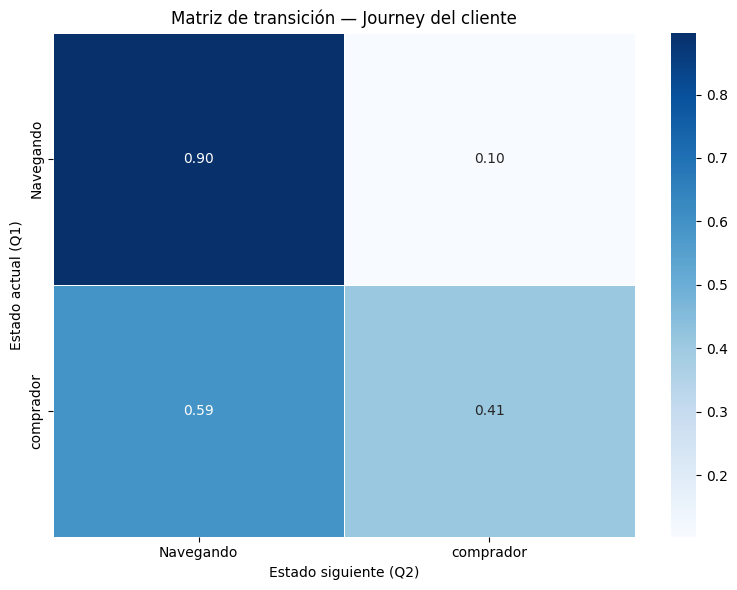

In [51]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues',
    linewidths=0.5
)
plt.title('Matriz de transición — Journey del cliente')
plt.xlabel('Estado siguiente (Q2)')
plt.ylabel('Estado actual (Q1)')
plt.tight_layout()
plt.show()

In [54]:
distribucion_real = transicion['estado q1'].value_counts(normalize=True)
print(distribucion_real.round(2))

estado q1
Navegando    0.86
comprador    0.14
Name: proportion, dtype: float64


In [57]:
estado_inicial = np.array([0.86, 0.14])

In [61]:
M = matriz.values
print('M=',M.round(2))

# Simular 3 quincenas hacia adelante
print('Estado inicial:        ', estado_inicial.round(2))
print('Después de 1 quincena: ', (estado_inicial @ M).round(2))
print('Después de 2 quincenas:', (estado_inicial @ M @ M).round(2))
print('Después de 3 quincenas:', (estado_inicial @ M @ M @ M).round(2))

M= [[0.9  0.1 ]
 [0.59 0.41]]
Estado inicial:         [0.86 0.14]
Después de 1 quincena:  [0.85 0.15]
Después de 2 quincenas: [0.85 0.15]
Después de 3 quincenas: [0.85 0.15]


In [66]:
#Caso hipotetico: Aumentamos la probabilidad de compradores en la primera quincena a 0.15

M_intervencion = M.copy()
M_intervencion[0, 0] = 0.8
M_intervencion[0, 1] = 0.2
print('M luego de intervenir:', M_intervencion.round(2))
# Simular 3 quincenas hacia adelante
print('Estado inicial:        ', estado_inicial.round(2))
print('Después de 1 quincena: ', (estado_inicial @ M).round(2))
print('Después de 2 quincenas luego de intervenir:', (estado_inicial @ M_intervencion @ M_intervencion).round(2))
print('Después de 3 quincenas luego de intervenir:', (estado_inicial @ M_intervencion @ M_intervencion @ M_intervencion).round(2))

M luego de intervenir: [[0.8  0.2 ]
 [0.59 0.41]]
Estado inicial:         [0.86 0.14]
Después de 1 quincena:  [0.85 0.15]
Después de 2 quincenas luego de intervenir: [0.75 0.25]
Después de 3 quincenas luego de intervenir: [0.75 0.25]


Sin intervención el sistema se estabiliza en 15% de compradores. Si aplicamos una estrategia de remarketing después de la primera quincena — cuando ya identificamos quiénes compraron y quiénes solo navegaron — podemos mejorar la conversión al 20% y el sistema converge a 25% de compradores en estado estacionario.

In [69]:
usuarios_totales = df['user_id'].nunique()
compradores_sin_intervencion = int(usuarios_totales * 0.15)
compradores_con_intervencion = int(usuarios_totales * 0.25)
dif = compradores_con_intervencion - compradores_sin_intervencion
print(f'Usuarios totales: {usuarios_totales}')
print(f'Compradores sin intervención: {compradores_sin_intervencion}')
print(f'Compradores con intervención: {compradores_con_intervencion}')
print(f'Aumento en compradores: {dif}')


Usuarios totales: 3022290
Compradores sin intervención: 453343
Compradores con intervención: 755572
Aumento en compradores: 302229


### Conclusion  
La matriz de markov nos permite conocer, en el momento actual, las probabilidades de los cambios de estado de los usuarios, en una linea de tiempo futura, sin embargo, esta no tiene en cuenta los datos pasados.
Segun la matriz que se contruye llega un estado estacionario el cual nos muestra que la cantidad de compradores sigue siendo la misma en el tiempo futuro, por lo que aca es donde surge imporante realizar campañas para aumentar esta probabilidad. 
Para este ejercicio se realizo una intervencio despues de la primera quincena, aumentando la cantidad de personas compradoras a un 20%, sin embargo el efecto de esta campaña llego a estado estacionario pronto, por lo que en este ejemplo resulta importante realizar intervenciones continuas